This script quickly opens up a grib2 file and prints the variables and metadata contained.

In [11]:
import xarray as xr
import cfgrib

# Path to GRIB2 file
grib_file = "/Users/ljob/Desktop/flxf2003010100.01.200301.avrg.grb2"

level = 'surface'

try:
    # Open the dataset
    ds = xr.open_dataset(
        grib_file,
        engine="cfgrib",
        filter_by_keys={'typeOfLevel': level}
    )

    print("\n=== Dataset Summary ===")
    print(ds)

    print("\n=== Variables ===")
    for var in ds.data_vars:
        print(f"\n{var}")
        print(f"  Long name : {ds[var].attrs.get('long_name', 'N/A')}")
        print(f"  Units     : {ds[var].attrs.get('units', 'N/A')}")
        print(f"  Shape     : {ds[var].shape}")
        print(f"  Dimensions: {ds[var].dims}")

except Exception as e:
    print(f"Error opening file: {e}")


=== Dataset Summary ===
<xarray.Dataset> Size: 14MB
Dimensions:      (latitude: 190, longitude: 384)
Coordinates:
  * latitude     (latitude) float64 2kB 89.28 88.34 87.4 ... -87.4 -88.34 -89.28
  * longitude    (longitude) float64 3kB 0.0 0.9375 1.875 ... 357.2 358.1 359.1
    time         datetime64[ns] 8B ...
    step         float64 8B ...
    surface      float64 8B ...
    valid_time   datetime64[ns] 8B ...
Data variables: (12/47)
    avg_utaua    (latitude, longitude) float32 292kB ...
    avg_vtaua    (latitude, longitude) float32 292kB ...
    avg_ishf     (latitude, longitude) float32 292kB ...
    avg_slhtf    (latitude, longitude) float32 292kB ...
    avg_t        (latitude, longitude) float32 292kB ...
    sdwe         (latitude, longitude) float32 292kB ...
    ...           ...
    snowc        (latitude, longitude) float32 292kB ...
    csdlf        (latitude, longitude) float32 292kB ...
    csusf        (latitude, longitude) float32 292kB ...
    csdsf        (latit

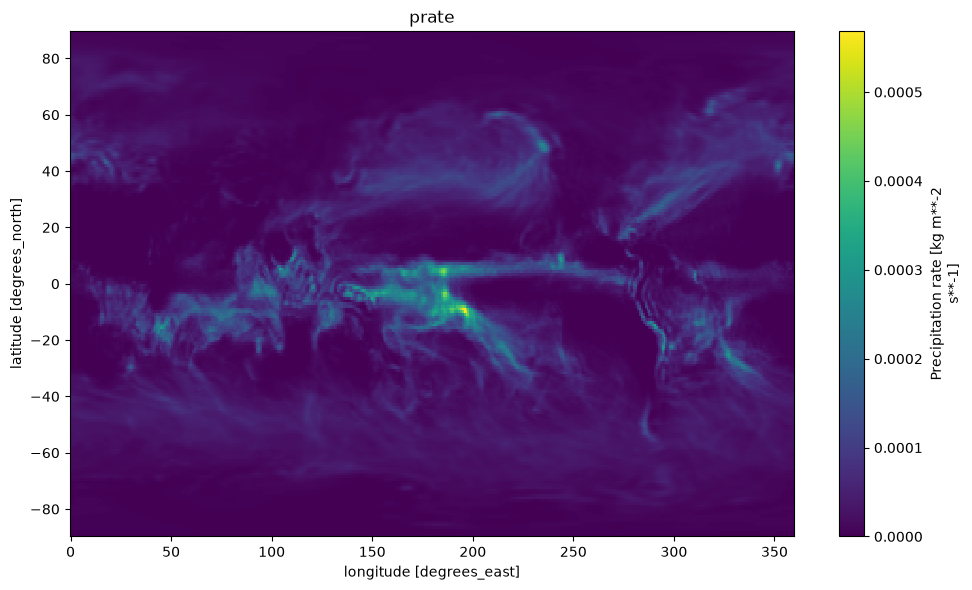

In [12]:
import matplotlib.pyplot as plt

variable = 'prate'
da = ds[variable]

plt.figure(figsize=(10, 6))
da.plot()

plt.title(variable)
plt.tight_layout()
plt.show()